Dataset Link: https://www.kaggle.com/datasets/gpreda/presidential-debate-video-comments

In [1]:
!pip install wordcloud pandas matplotlib textblob --quiet

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud, STOPWORDS
import re


In [3]:
data = pd.read_csv("presidential_debate_video_comments.tab", sep="\t")

In [4]:
data.columns

Index(['id', 'replyCount', 'likeCount', 'publishedAt', 'authorName', 'text',
       'authorChannelId', 'authorChannelUrl', 'isReply', 'isReplyTo',
       'isReplyToName'],
      dtype='str')

In [5]:
data.head()

,id,replyCount,likeCount,publishedAt,authorName,text,authorChannelId,authorChannelUrl,isReply,isReplyTo,isReplyToName
0,UgyP_SwgxW5HoHr8Knx4AaABAg,0.0,1,2020-09-30 22:04:09,Lilqc,this is like 9 yr old roast battles honestly,UCJUZ1gzyRNv7oP6RWBsna0Q,http://www.youtube.com/channel/UCJUZ1gzyRNv7oP...,0,NaN,NaN
1,UgzUhRrJhJteT-7Guwl4AaABAg,0.0,0,2020-09-30 22:04:08,archiewu,Asian Commentators:<br /><br />Two 70 year old...,UC9ggYYLWxiTC_gl3EiuYJ8w,http://www.youtube.com/channel/UC9ggYYLWxiTC_g...,0,NaN,NaN
2,Ugz_hPcVTWPiBT7juzZ4AaABAg,0.0,0,2020-09-30 22:04:07,Giselle Perez,DID HE SAY KILLING PEOPLE??,UCPpfI3ORHn1vAbA63gQc2Iw,http://www.youtube.com/channel/UCPpfI3ORHn1vAb...,0,NaN,NaN
3,Ugxa2pocGhxm-yRFlTp4AaABAg,0.0,0,2020-09-30 22:03:41,Rock Styler,Forget this debate and let&#39;s move on to th...,UCi7T72WC0Z3HDA3G5-iOw6Q,http://www.youtube.com/channel/UCi7T72WC0Z3HDA...,0,NaN,NaN
4,Ugy1AXbUSTPzaY5DN614AaABAg,0.0,0,2020-09-30 22:03:39,Yung Famous,I LOVE THIS DEBATE,UCYVgVlPDlx5O-307u8Z9ePQ,http://www.youtube.com/channel/UCYVgVlPDlx5O-3...,0,NaN,NaN


In [6]:
print(data.info())
print(f"Total comments: {len(data)}")

<class 'pandas.DataFrame'>
RangeIndex: 23682 entries, 0 to 23681
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                23682 non-null  str    
 1   replyCount        12449 non-null  float64
 2   likeCount         23682 non-null  int64  
 3   publishedAt       23682 non-null  str    
 4   authorName        23676 non-null  str    
 5   text              23682 non-null  str    
 6   authorChannelId   23679 non-null  str    
 7   authorChannelUrl  23679 non-null  str    
 8   isReply           23682 non-null  int64  
 9   isReplyTo         11233 non-null  str    
 10  isReplyToName     11233 non-null  str    
dtypes: float64(1), int64(2), str(8)
memory usage: 2.0 MB
None
Total comments: 23682


In [7]:
data['publishedAt'] = pd.to_datetime(data['publishedAt'])

In [8]:
print(data[['likeCount', 'replyCount']].describe())

          likeCount    replyCount
count  23682.000000  12449.000000
mean       6.950553      0.901599
std       44.783604      3.477416
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        2.000000      0.000000
max     1782.000000    155.000000


In [ ]:
#  1: Top 10 most liked comments
top_liked = data.sort_values('likeCount', ascending=False).head(10)
print(top_liked[['authorName', 'likeCount', 'text']])

              authorName  likeCount  \
9713        M. Al-Ghayeb       1782   
9563            musyrifo       1682   
7177       Ronald Parker       1481   
5458            klaas809       1305   
5837          Ho Lii Fuk       1219   
11746         Mo0oo 6778       1219   
18548  dholl synth music       1039   
19889     Antoine Troupe        947   
17346               SLPC        916   
12085           musyrifo        875   

                                                    text  
9713   2010: watching movies for entertainment <br />...  
9563   Americans: worried about their country&#39;s f...  
7177   Chris Wallace really was treated like a subsit...  
5458    As a non American, this was highly entertaining.  
5837   The whole debate in a nutshell<br />1. Mr. Pre...  
11746  Who needs Netflix when you have American polit...  
18548  Conclusion:<br />1) Trump performed as expecte...  
19889  its like you laugh....but you&#39;re also terr...  
17346  I&#39;m 98% sure Trump&#39;s goa

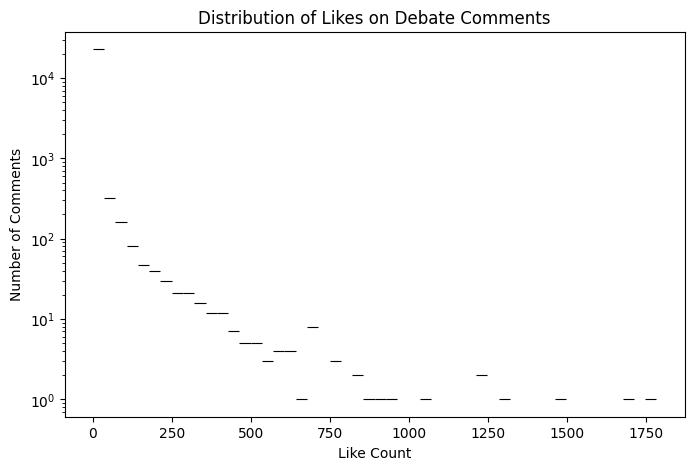

In [ ]:
#  2: Distribution of likes
plt.figure(figsize=(8,5))
sns.histplot(data['likeCount'], bins=50, log_scale=(False, True))  # log-scale for better visibility
plt.title("Distribution of Likes on Debate Comments")
plt.xlabel("Like Count")
plt.ylabel("Number of Comments")
plt.show()

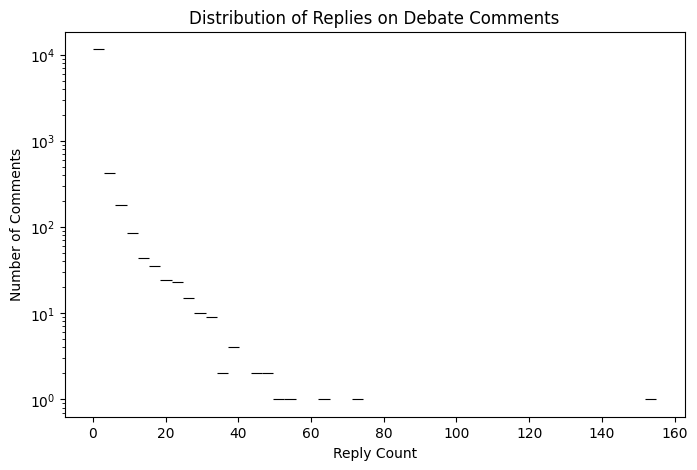

In [ ]:
#  3: Distribution of replies
plt.figure(figsize=(8,5))
sns.histplot(data['replyCount'], bins=50, log_scale=(False, True))
plt.title("Distribution of Replies on Debate Comments")
plt.xlabel("Reply Count")
plt.ylabel("Number of Comments")
plt.show() 

In [12]:
# TEXT CLEANING (basic)
import re
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)  # remove non-alphabet
    return text

data['clean_text'] = data['text'].apply(clean_text)

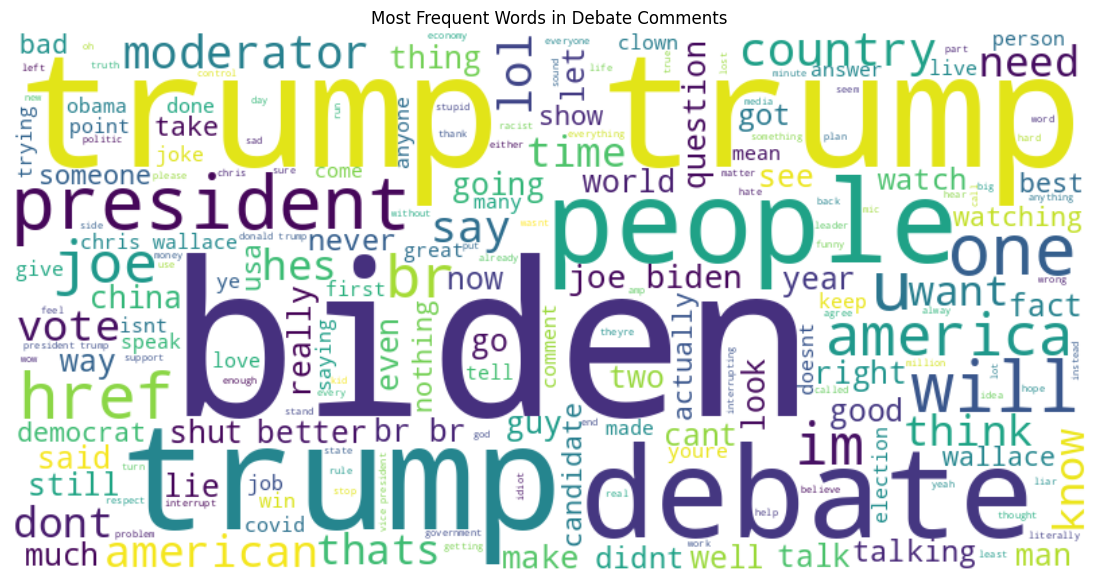

In [13]:
# WORD CLOUD
all_text = " ".join(data['clean_text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200).generate(all_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in Debate Comments")
plt.show()

In [14]:
# SENTIMENT ANALYSIS
def get_sentiment(text):
    analysis = TextBlob(str(text))
    return analysis.polarity  # -1 to +1

data['sentiment'] = data['text'].apply(get_sentiment)

# Categorize sentiment
def categorize_sentiment(p):
    if p > 0.05:
        return 'Positive'
    elif p < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

data['sentiment_label'] = data['sentiment'].apply(categorize_sentiment)

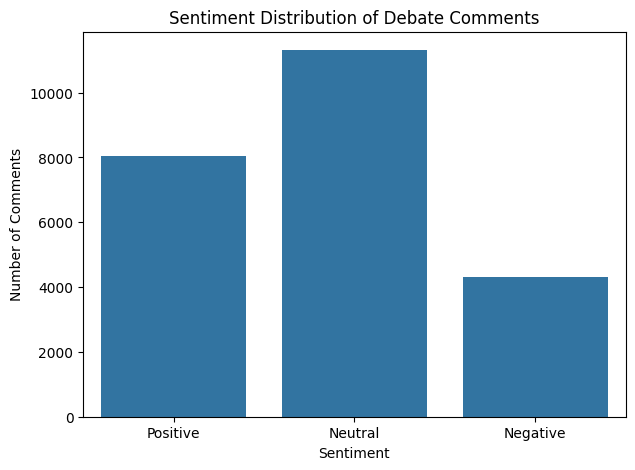

In [15]:
# 1. Sentiment distribution
plt.figure(figsize=(7,5))
sns.countplot(x='sentiment_label', data=data, order=['Positive', 'Neutral', 'Negative'])
plt.title("Sentiment Distribution of Debate Comments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()


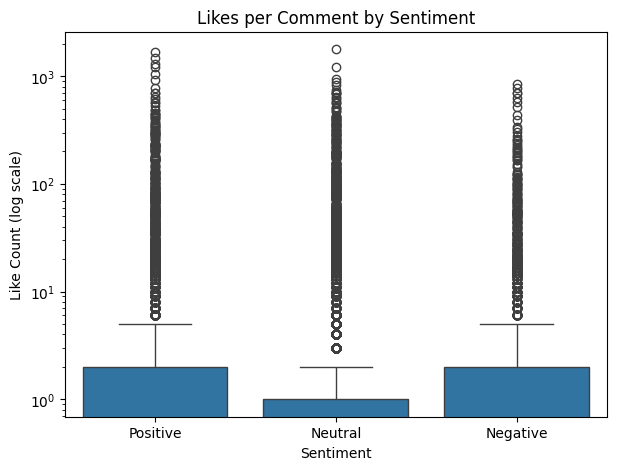

In [16]:
# 2. Likes vs Sentiment
plt.figure(figsize=(7,5))
sns.boxplot(x='sentiment_label', y='likeCount', data=data)
plt.yscale('log')  # log scale for skewed data
plt.title("Likes per Comment by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Like Count (log scale)")
plt.show()

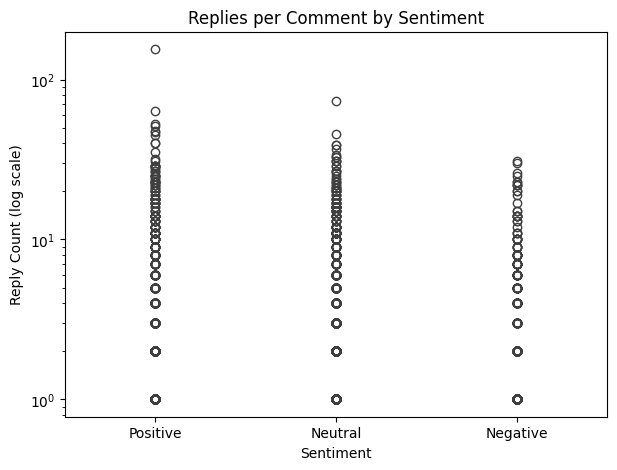

In [17]:
# 3. Replies vs Sentiment
plt.figure(figsize=(7,5))
sns.boxplot(x='sentiment_label', y='replyCount', data=data)
plt.yscale('log')
plt.title("Replies per Comment by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Reply Count (log scale)")
plt.show()

[nltk_data] Downloading package stopwords to /home/larson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


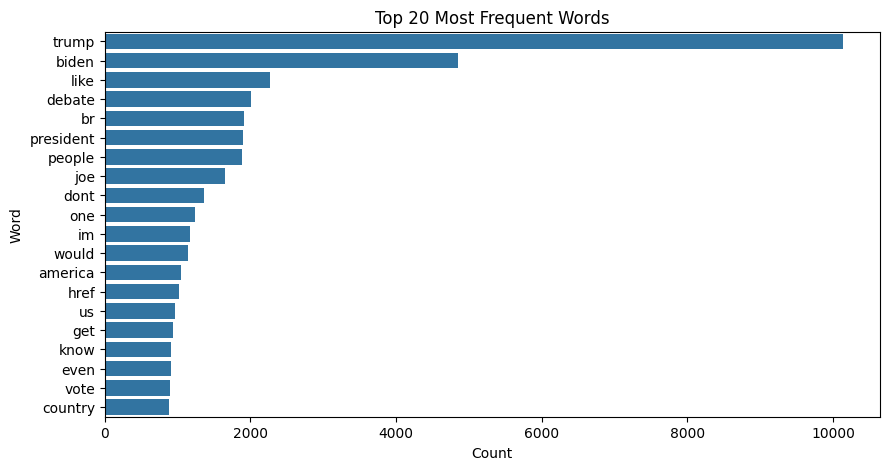

In [18]:
# 4. Top 20 most frequent words (excluding stopwords)
from collections import Counter
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

words = [word for word in all_text.split() if word not in stop_words]
top_words = Counter(words).most_common(20)
top_words_df = pd.DataFrame(top_words, columns=['word','count'])

plt.figure(figsize=(10,5))
sns.barplot(x='count', y='word', data=top_words_df)
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

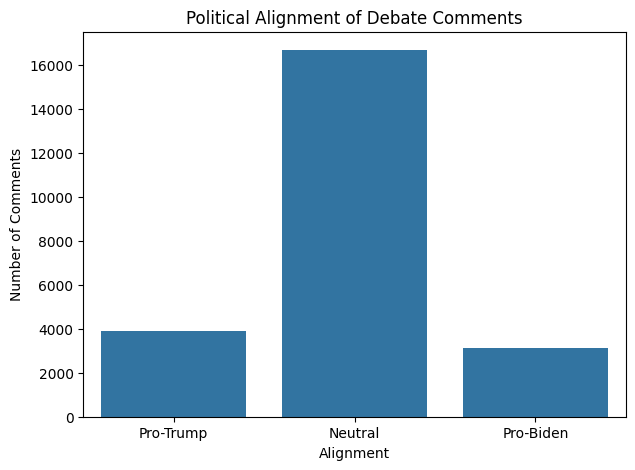

In [19]:
# Define keywords for Trump and Biden
trump_keywords = ["trump", "maga", "donald", "president trump", "45th president"]
biden_keywords = ["biden", "joe", "joebiden", "president biden", "democrat"]

# Function to classify comments
def political_alignment(comment):
    comment_lower = str(comment).lower()
    trump_score = sum([1 for kw in trump_keywords if kw in comment_lower])
    biden_score = sum([1 for kw in biden_keywords if kw in comment_lower])
    
    if trump_score > biden_score:
        return "Pro-Trump"
    elif biden_score > trump_score:
        return "Pro-Biden"
    else:
        return "Neutral"

# Apply classification
data['political_alignment'] = data['text'].apply(political_alignment)

# Distribution of comments
plt.figure(figsize=(7,5))
sns.countplot(x='political_alignment', data=data, order=['Pro-Trump','Neutral','Pro-Biden'])
plt.title("Political Alignment of Debate Comments")
plt.xlabel("Alignment")
plt.ylabel("Number of Comments")
plt.show()

In [20]:
print("Sime Pro-Trump Comments:")
data[data['political_alignment']=="Pro-Trump"]['text'].sample(5, random_state=42).tolist()

Sime Pro-Trump Comments:


['*Clownald Trump*',
 "@StopBeingAKeyBoardKiller&MousePadMobster! So far I do not know if Biden is a white supremacist. Certainly, his support of the 1994 crime bill does not convince of that. Most likely it was a convenient political position to have at that time. All I know is, we have already been in the darkness where Donald Trump is taking us to. It's not pretty. We are the envy of every country on earth, do you think we should put humanity in turmoil because this man is power drunk?",
 'liar trump NEVER intends, nor does\xa0HIS repukeican party, to offer\xa0a healthcare PLAN. he and his corporate stooges DO NOT want to afford the American worker ANY such thing. NEVER mind that EVERY other industrialized nation SEES VALUE in taking care of their citizen work force. it is true that it is cheaper to die. $ is their objection. never mind the VAST problems it would solve.',
 'It was more like a Trump - Wallace, debate.... Wallace came back and argued against Trumps answers personally 

In [21]:
print("\nSome Pro-Biden Comments:")
data[data['political_alignment']=="Pro-Biden"]['text'].sample(5, random_state=42).tolist()


Some Pro-Biden Comments:


['if biden win,china win',
 'Joe Lair',
 'Joe Biden &amp; Democratic Party will end up destroying America if elected.Donald J Trump is the only option here',
 'Train wreck....lol poor Biden.',
 '@Dark Dragon You may want to go for a mental evaluation. Wallace was CLEARLY Biased for Biden, Just look at every other comment on the video. I hope one day you take off your rose-tinted Democrat glasses off. TDS is real.']

In [22]:
print("\nSome Neutral Comments:")
data[data['political_alignment']=="Neutral"]['text'].sample(5, random_state=42).tolist()


Some Neutral Comments:


['Moderator......<br /><br />You are not for American....traitor',
 'Trueeeeeeee🗣',
 'and what of young corn pop? I hear he is a bad dude!',
 "I know, I mean look at Canadian elections debate last year Its a mess. Especially the moderators, they give time to party leaders to make up a point within 30s, that's BS.",
 'The whole point of a debate is to argue and not just offer statements. Interruptions are part of the process.']